## Algoritmo KNN

In [1]:
#importamos
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
ConfusionMatrixDisplay
)

## cargamos el dataset

In [3]:
iris = load_iris(as_frame=True)

In [4]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
dfIris = iris.frame
dfIris.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [6]:
dfIris.tail(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
#cambiamos la columna target por especie
dfIris.rename(columns={"target" : "species"}, inplace=True)

In [9]:
#remplazamos los valores numericos por las especies
dfIris["species"] = dfIris["species"].map(
    {
        0: "setosa",
        1: "versicolor",
        2: "virginica"
    }
)

In [10]:
dfIris.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## variables predictoras y variables objetivo
X (variables predictoras) son aquellas que permiten hacer la prediccion
y (objetivo) lo que quiero predecir

In [11]:
#variables predictoras
X = dfIris.drop(columns=["species"])

In [12]:
#varible objetivo
y = dfIris["species"]

In [13]:
print("----varibles predictoras----")
print(X.columns)
print("----varible objetivo----")
print(y.name)

----varibles predictoras----
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')
----varible objetivo----
species


#division del conjunto de datos
training set: datos de entrenamiento (80%)
testing set: datos no vistos por el modelo, para prueba (20%)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, #variables predictoras
    y, #variable objetivo
    test_size = 0.20,
    random_state=42,
    stratify=y
)

In [15]:
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("-----------------------")
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (120, 4)
X_test:  (30, 4)
-----------------------
y_train:  (120,)
y_test:  (30,)


## escalado de las variables

In [16]:
scaler = StandardScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
print("--------datos sin escalar--------")
print(X_train.head(5))
print("--------escalados--------")
print(X_train_scaled[:5])

--------datos sin escalar--------
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
8                  4.4               2.9                1.4               0.2
106                4.9               2.5                4.5               1.7
76                 6.8               2.8                4.8               1.4
9                  4.9               3.1                1.5               0.1
89                 5.5               2.5                4.0               1.3
--------escalados--------
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


## entrenamiento del modelo

In [19]:
#creamos una instancia del algoritmo 
modelo = KNeighborsClassifier(
    n_neighbors = 3
)

In [20]:
#entrenamos con los datos de entrenamiento
modelo.fit(
    X_train_scaled,
    y_train
)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
prediccion = modelo .predict(X_test_scaled)

In [22]:
pd.DataFrame({
    "Espacie real" : y_test.values,
    "Espacie predicha" : prediccion
}).head(20)

,Espacie real,Espacie predicha
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


## EVALUACION DEL MODELO

`las metricas son : accuracy, precision, recall, f1-score

In [23]:
#Accuracy
accuracy = accuracy_score(y_test, prediccion)

In [24]:
print ( f"Accuracy / Exactitud del modelo es: {accuracy: .4f}")

Accuracy / Exactitud del modelo es:  0.9333


In [25]:
#Matriz de confusion

matrizConfusion = confusion_matrix(y_test, prediccion)
matrizConfusion_df = pd.DataFrame(
    matrizConfusion,
    index = modelo.classes_,
    columns = modelo.classes_
)

In [26]:
matrizConfusion_df

,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,10,0
virginica,0,2,8


In [27]:
#Mat# Matriz de metricas: Classification Report
print ( classification_report(y_test, prediccion))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## Variables de importancia 

In [28]:
## importancia = modelo.feature_importances_
corr = dfIris.corr(numeric_only=True)

<Axes: >

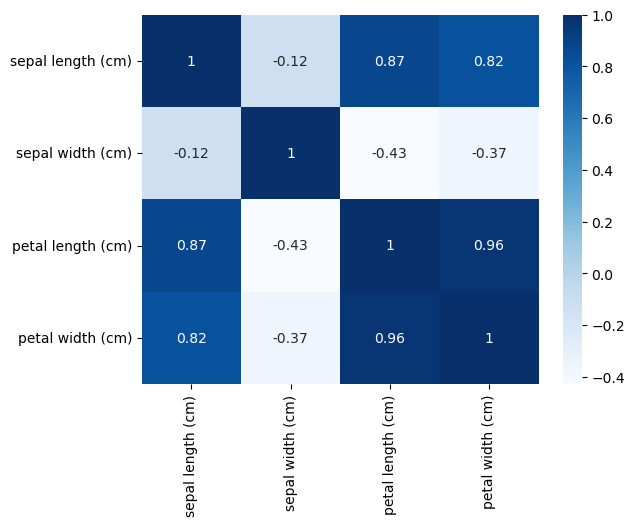

In [30]:
import seaborn as sns
sns.heatmap ( corr, annot=True, cmap="Blues")